# RetailRocket: dataset QA and train/test split

This notebook explains **what data we use**, **how sequences are built**, and **how the time-based train/test split works**.


In [1]:
%matplotlib inline
from pathlib import Path
import sys

# Ensure `import src...` works regardless of where the kernel starts.
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_PATH = ROOT / 'data/raw/retailrocket/events.csv'
QA_DIR = ROOT / 'results/retailrocket/qa-full/qa'

print('ROOT:', ROOT)
print('DATA_PATH:', DATA_PATH)
print('DATA_PATH exists:', DATA_PATH.exists())
print('QA_DIR:', QA_DIR)
print('QA_DIR exists:', QA_DIR.exists())


ROOT: /Users/amosh239/repo/mkn/Hawk's proccess
DATA_PATH: /Users/amosh239/repo/mkn/Hawk's proccess/data/raw/retailrocket/events.csv
DATA_PATH exists: True
QA_DIR: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket/qa-full/qa
QA_DIR exists: True


## Quick QA (full file, cached)
We cache basic QA stats under `results/retailrocket/qa-full/qa/`. If it's missing, we run the QA script once.


In [2]:
import json
import subprocess
import pandas as pd

if not QA_DIR.exists():
    # ~20s on the full RetailRocket events.csv (90MB)
    py = ROOT / '.venv/bin/python'
    python = str(py) if py.exists() else sys.executable
    subprocess.check_call([python, str(ROOT / 'scripts/qa_retailrocket.py'), '--run-id', 'qa-full'])

qa_summary = json.loads((QA_DIR / 'qa_summary.json').read_text(encoding='utf-8'))
df_grid = pd.read_csv(QA_DIR / 'filter_grid.csv')

print('Event counts:', qa_summary['event_counts'])
print('Unique visitors:', qa_summary['unique_visitors'])
print('Time range:', qa_summary['time_min'], '->', qa_summary['time_max'])


Event counts: {'view': 2664312, 'addtocart': 69332, 'transaction': 22457}
Unique visitors: 1407580
Time range: 2015-05-03T03:00:04.384000 -> 2015-09-18T02:59:47.788000


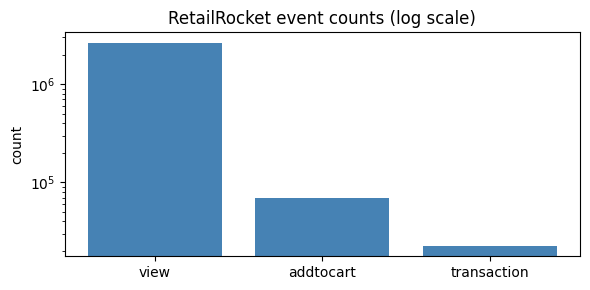

In [3]:
import numpy as np
import matplotlib.pyplot as plt

events = list(qa_summary['event_counts'].keys())
counts = [qa_summary['event_counts'][e] for e in events]

plt.figure(figsize=(6, 3))
plt.bar(events, counts, color='steelblue')
plt.yscale('log')
plt.title('RetailRocket event counts (log scale)')
plt.ylabel('count')
plt.tight_layout()


## How we build sequences
We group events by **visitorid** and sort by time. Each sequence contains:
- `times`: timestamps
- `types`: event type ids (`view=0`, `addtocart=1`, `transaction=2`)

Code: `src/datasets/retailrocket.py` (loader)


In [4]:
from src.datasets import EVENT_MAP
EVENT_MAP


{'view': 0, 'addtocart': 1, 'transaction': 2}

## Train/test split (time-based, per visitor)
For each visitor sequence we compute:
- `t_start = first event time`
- `t_end = last event time`
- `split_point = t_start + train_ratio * (t_end - t_start)`

Events with `t <= split_point` go to train; the rest go to test.

Code: `src/utils.py:temporal_train_test_split`


In [5]:
import pandas as pd
from src.utils import temporal_train_test_split

# Show how many visitors have a transaction AFTER the split point (depends on train_ratio + min_events).
pivot = df_grid.pivot(index='min_events', columns='train_ratio', values='with_test_transaction')
pivot


train_ratio,0.5,0.6,0.7,0.8
min_events,,,,
5,4571,4372,4176,3944
10,2067,1951,1830,1700
20,872,812,743,665
30,535,494,452,390
50,294,277,253,217
80,184,172,161,142


### Why do many users have `purchases_test == 0`?
Transactions are rare events. With a time split, many visitors simply have **no transactions in the test window**.
This is *not* necessarily a bug; it's a property of the funnel.


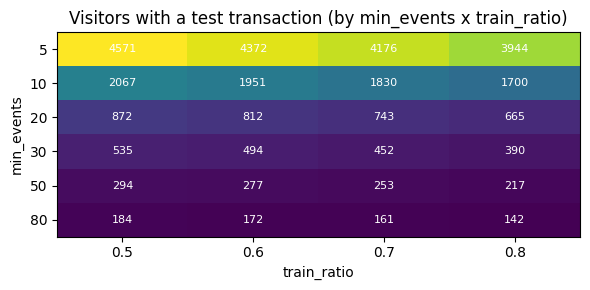

In [6]:
# Optional: visualize the grid as a heatmap
plt.figure(figsize=(6, 3))
z = pivot.values.astype(float)
plt.imshow(z, aspect='auto')
plt.title('Visitors with a test transaction (by min_events x train_ratio)')
plt.xlabel('train_ratio')
plt.ylabel('min_events')
plt.xticks(range(pivot.shape[1]), [str(c) for c in pivot.columns])
plt.yticks(range(pivot.shape[0]), [str(i) for i in pivot.index])
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        plt.text(j, i, str(int(z[i, j])), ha='center', va='center', fontsize=8, color='white')
plt.tight_layout()


## Inspect one real visitor timeline
We pick a visitor from the latest experiment run (with at least one test transaction) and plot their event timeline with the split point.


In [7]:
# Pick latest run automatically (or set RUN_ID manually)
RUN_ID = None  # e.g. 'retailrocket-20260126-183513'
runs = sorted((ROOT / 'results/retailrocket').glob('retailrocket-*'))
if not runs:
    raise FileNotFoundError('No runs found under results/retailrocket/. Run: scripts/run_real.py')
RUN_DIR = (ROOT / 'results/retailrocket' / RUN_ID) if RUN_ID else runs[-1]

df_run = pd.read_csv(RUN_DIR / 'summary.csv')
print('RUN_DIR:', RUN_DIR)
print('rows:', len(df_run))
print('purchases_test==0:', int((df_run.purchases_test == 0).sum()))

cand = df_run[df_run.purchases_test > 0].sort_values('ll_gain', ascending=False)
if len(cand) == 0:
    raise ValueError('No sequences with purchases_test>0 in this run. Try another RUN_ID or change train_ratio.')
seq_id = int(cand.iloc[0].seq_id)
print('Example seq_id (visitorid):', seq_id)


RUN_DIR: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket/retailrocket-20260126-183513
rows: 78
purchases_test==0: 55
Example seq_id (visitorid): 109357


In [8]:
# Load events for one visitor (streaming read; avoids loading the full 2.7M rows in RAM)
def load_visitor_events(path, visitorid, chunksize=500_000):
    usecols = ['timestamp', 'visitorid', 'event']
    parts = []
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize):
        m = chunk['visitorid'].astype('int64') == int(visitorid)
        if m.any():
            parts.append(chunk.loc[m, usecols])
    if not parts:
        return pd.DataFrame(columns=usecols + ['ts', 'type_id'])
    df = pd.concat(parts, ignore_index=True)
    df = df[df['event'].isin(EVENT_MAP.keys())].copy()
    df['ts'] = pd.to_datetime(df['timestamp'], unit='ms')
    df['type_id'] = df['event'].map(EVENT_MAP)
    return df.sort_values('ts')

df_v = load_visitor_events(DATA_PATH, seq_id)
print('events:', len(df_v))
print(df_v['event'].value_counts())


events: 101
event
view           46
addtocart      36
transaction    19
Name: count, dtype: int64


In [9]:
# Compute split point (same logic as src/utils.py:temporal_train_test_split)
train_ratio = 0.8
times = df_v['ts'].tolist()
types = df_v['type_id'].tolist()
train_times, test_times, train_types, test_types = temporal_train_test_split(times, types, train_ratio=train_ratio)

t_start = times[0]
duration_sec = (times[-1] - t_start).total_seconds()
split_point = t_start + pd.Timedelta(seconds=duration_sec * train_ratio)

p_train = sum(int(x == EVENT_MAP['transaction']) for x in (train_types or []))
p_test = sum(int(x == EVENT_MAP['transaction']) for x in (test_types or []))

print('train_ratio:', train_ratio)
print('split_point:', split_point)
print('purchases_train:', p_train)
print('purchases_test:', p_test)


train_ratio: 0.8
split_point: 2015-05-29 23:07:49.500400
purchases_train: 12
purchases_test: 7


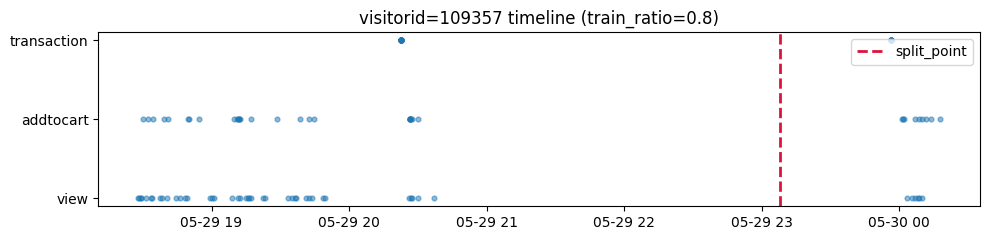

In [10]:
plt.figure(figsize=(10, 2.5))
plt.scatter(df_v['ts'], df_v['type_id'], s=12, alpha=0.5)
plt.axvline(split_point, color='crimson', linestyle='--', linewidth=2, label='split_point')
plt.yticks([0, 1, 2], ['view', 'addtocart', 'transaction'])
plt.title(f'visitorid={seq_id} timeline (train_ratio={train_ratio})')
plt.legend(loc='upper right')
plt.tight_layout()
